<div style="
    background: linear-gradient(135deg, rgba(255,255,255,0.85), rgba(240,253,250,0.9));
    backdrop-filter: blur(10px);
    color: #0f172a;
    font-weight: 900;
    padding: 30px;
    border-radius: 26px;
    text-align: center;
    font-size: 32px;
    box-shadow:
        0 12px 28px rgba(15,23,42,0.25),
        inset 0 0 18px rgba(45,212,191,0.35);
    font-family: 'Poppins', 'Segoe UI', sans-serif;
    letter-spacing: 1.1px;
">
    🚗 <span style="
        background: linear-gradient(90deg, #f97316, #14b8a6);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
    ">
        Automobile Performance Insights
    </span><br>
    <span style="color:#334155; font-weight:700;">
        Through Advanced Statistical Analysis (Auto MPG Dataset)
    </span>
</div>



<div style="
    background: linear-gradient(135deg, #020617, #0f172a, #020617);
    color: #f8fafc;
    font-weight: 800;
    padding: 22px; 
    border-radius: 16px; 
    text-align: center;
    font-size: 30px;
    box-shadow: 
        0 10px 30px rgba(6,182,212,0.35),
        inset 0 0 15px rgba(250,204,21,0.25);
    font-family: 'Segoe UI', 'Poppins', Arial, sans-serif;
    letter-spacing: 1px;
">
    ⚙️ <span style="color:#06b6d4;">Import Libraries</span> • 
    <span style="color:#facc15;">Statistical Methods</span> • 
    <span style="color:#a78bfa;">Algorithms</span> • 
    <span style="color:#22c55e;">Metrics</span>
</div>


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder ,StandardScaler
from scipy import stats
from statsmodels.stats.weightstats import ztest
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\auto-mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [3]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [6]:
for x in df:
    print(x)
    print(df[x].unique())
    print(df[x].nunique())

mpg
[18.  15.  16.  17.  14.  24.  22.  21.  27.  26.  25.  10.  11.   9.
 28.  19.  12.  13.  23.  30.  31.  35.  20.  29.  32.  33.  17.5 15.5
 14.5 22.5 24.5 18.5 29.5 26.5 16.5 31.5 36.  25.5 33.5 20.5 30.5 21.5
 43.1 36.1 32.8 39.4 19.9 19.4 20.2 19.2 25.1 20.6 20.8 18.6 18.1 17.7
 27.5 27.2 30.9 21.1 23.2 23.8 23.9 20.3 21.6 16.2 19.8 22.3 17.6 18.2
 16.9 31.9 34.1 35.7 27.4 25.4 34.2 34.5 31.8 37.3 28.4 28.8 26.8 41.5
 38.1 32.1 37.2 26.4 24.3 19.1 34.3 29.8 31.3 37.  32.2 46.6 27.9 40.8
 44.3 43.4 36.4 44.6 40.9 33.8 32.7 23.7 23.6 32.4 26.6 25.8 23.5 39.1
 39.  35.1 32.3 37.7 34.7 34.4 29.9 33.7 32.9 31.6 28.1 30.7 24.2 22.4
 34.  38.  44. ]
129
cylinders
[8 4 6 3 5]
5
displacement
[307.  350.  318.  304.  302.  429.  454.  440.  455.  390.  383.  340.
 400.  113.  198.  199.  200.   97.  110.  107.  104.  121.  360.  140.
  98.  232.  225.  250.  351.  258.  122.  116.   79.   88.   71.   72.
  91.   97.5  70.  120.   96.  108.  155.   68.  114.  156.   76.   83.
  90.  231. 

<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    EDA
</div>


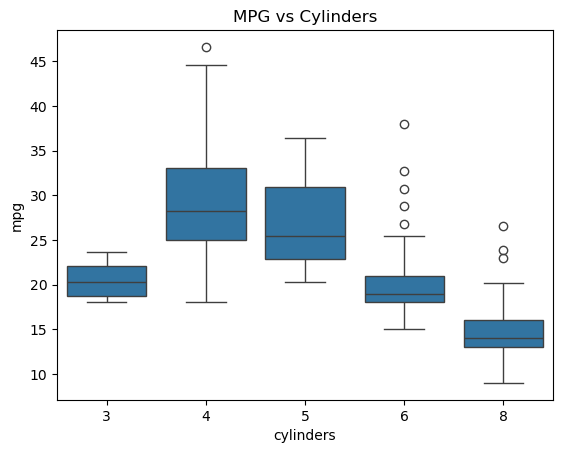

In [7]:
sns.boxplot(x='cylinders', y='mpg', data=df)
plt.title("MPG vs Cylinders")
plt.show()


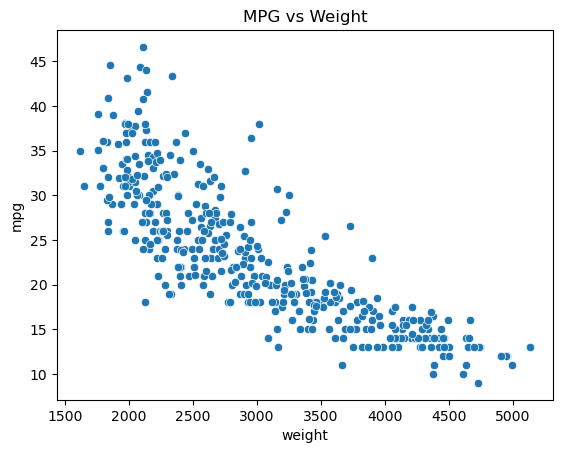

In [8]:
sns.scatterplot(x='weight', y='mpg', data=df)
plt.title("MPG vs Weight")
plt.show()


<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    Hypothesis test in Z-test
</div>


### Null Hypothesis (H₀):
    There is no significant difference in the average mileage between USA and European cars.

### Alternative Hypothesis (H₁):
     There is a significant difference in the average mileage between USA and European cars.​


In [9]:
from statsmodels.stats.weightstats import ztest

mpg_usa = df[df['origin'] == 1]['mpg']
mpg_europe = df[df['origin'] == 2]['mpg']

z_stat, p_value = ztest(mpg_usa, mpg_europe, value=0)

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: -8.914687150324422
P-value: 4.891954458316858e-19


In [10]:
mpg_data = df['mpg']

z_stat, p_value = ztest(mpg_data, value=30)

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: -16.55375187908851
P-value: 1.5042874583030382e-61


In [11]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis (mean mpg is significantly different from 30)")
else:
    print("Fail to reject the null hypothesis (mean mpg is not significantly different from 30)")


Reject the null hypothesis (mean mpg is significantly different from 30)


<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    T-Test
</div>


### Null Hypothesis (H₀):
       There is no significant difference in the average mileage between cars with 304 displacement and 151 displacement.
### Alternative Hypothesis (H₁):
       There is a significant difference in the average mileage between cars with 304 displacement and 151 displacement.

In [12]:
mpg_usa = df[df['displacement'] == 304]['mpg']
mpg_europe = df[df['displacement'] == 151]['mpg']

In [13]:
t_stat, p_value = ttest_ind(mpg_usa, mpg_europe, equal_var=False)

In [14]:
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -8.912417034428294
P-value: 3.232931778033301e-07


In [15]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 → Significant difference in MPG")
else:
    print("Fail to reject H0 → No significant difference in MPG")

Reject H0 → Significant difference in MPG


<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    Chi2-Test
</div>


In [16]:
categorical_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model year', 'origin', 'car name']

In [17]:
table = pd.crosstab(df['origin'], df['mpg'])
print("Contingency Table:\n", table)


Contingency Table:
 mpg     9.0   10.0  11.0  12.0  13.0  14.0  14.5  15.0  15.5  16.0  ...  39.4  \
origin                                                              ...         
1          1     2     4     6    20    19     1    16     5    13  ...     0   
2          0     0     0     0     0     0     0     0     0     0  ...     0   
3          0     0     0     0     0     0     0     0     0     0  ...     1   

mpg     40.8  40.9  41.5  43.1  43.4  44.0  44.3  44.6  46.6  
origin                                                        
1          0     0     0     0     0     0     0     0     0  
2          0     1     1     1     1     1     1     0     0  
3          1     0     0     0     0     0     0     1     1  

[3 rows x 129 columns]


In [18]:
chi2, p, dof, expected = chi2_contingency(table)


In [19]:
print("\nChi-square value:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("\nExpected frequencies:\n", expected)



Chi-square value: 399.7907088958549
P-value: 2.1779700408579614e-08
Degrees of freedom: 256

Expected frequencies:
 [[ 0.62562814  1.25125628  2.50251256  3.75376884 12.51256281 11.88693467
   0.62562814 10.01005025  3.1281407   8.13316583  0.62562814  1.87688442
   0.62562814  4.37939698  3.1281407   1.25125628  0.62562814 10.63567839
   1.25125628  0.62562814  1.87688442  0.62562814  7.50753769  0.62562814
   1.87688442  1.25125628  0.62562814  0.62562814  5.63065327  2.50251256
   0.62562814  1.87688442  1.25125628  0.62562814  5.00502513  0.62562814
   1.87688442  0.62562814  6.25628141  0.62562814  0.62562814  0.62562814
   6.25628141  0.62562814  0.62562814  0.62562814  0.62562814  0.62562814
   1.25125628  6.88190955  0.62562814  0.62562814  1.25125628  6.88190955
   0.62562814  1.25125628  1.25125628  0.62562814  8.75879397  0.62562814
   0.62562814  1.25125628  0.62562814  5.63065327  1.87688442  0.62562814
   0.62562814  0.62562814  6.25628141  0.62562814  0.62562814  0.6256

In [20]:
alpha = 0.05
if p < alpha:
    print("\nReject H0 → Significant relationship between origin and mpg")
else:
    print("\nFail to reject H0 → No significant relationship between origin and mpg")


Reject H0 → Significant relationship between origin and mpg


<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    Anova
</div>


In [21]:
anova_data = df[['cylinders', 'mpg']]
anova_data

,cylinders,mpg
0,8,18.0
1,8,15.0
2,8,18.0
3,8,16.0
4,8,17.0
...,...,...
393,4,27.0
394,4,44.0
395,4,32.0
396,4,28.0


In [22]:

groups = anova_data.groupby('cylinders')['mpg'].apply(list)

f_statistic, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There are significant differences between the groups.")
else:
    print("There are no significant differences between the groups.")

F-statistic: 172.59178530289103
P-value: 3.679939295400875e-85
There are significant differences between the groups.


<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
     Spearman Rank Test
</div>


## Null Hypothesis (H₀):
     There is no monotonic relationship between MPG and acceleration.
## Alternative Hypothesis (H₁):
     There is a significant monotonic relationship between MPG and acceleration.

#### Mpg vs acceleration

In [48]:
from scipy.stats import spearmanr

r, p = spearmanr(df['mpg'], df['acceleration'])
print("Spearman r:", r)
print("p-value:", p)


Spearman r: 0.4386774795708622
p-value: 3.7760574238172543e-20


The Spearman rank correlation test is a non-parametric statistical test used to measure the strength and direction of a monotonic relationship between two variables. It works on the ranks of the data rather than the raw values, so it does not require the data to be normally distributed and is suitable for both linear and non-linear relationships.

<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    Model Building
</div>


In [23]:
le=LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [24]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,15,3504,12.0,70,1,49
1,15.0,8,350.0,33,3693,11.5,70,1,36
2,18.0,8,318.0,27,3436,11.0,70,1,231
3,16.0,8,304.0,27,3433,12.0,70,1,14
4,17.0,8,302.0,22,3449,10.5,70,1,161
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,80,2790,15.6,82,1,153
394,44.0,4,97.0,51,2130,24.6,82,2,301
395,32.0,4,135.0,78,2295,11.6,82,1,119
396,28.0,4,120.0,73,2625,18.6,82,1,159


In [25]:
df["car name"]

0       49
1       36
2      231
3       14
4      161
      ... 
393    153
394    301
395    119
396    159
397     69
Name: car name, Length: 398, dtype: int64

In [26]:
x=df.drop('mpg',axis=1)

In [27]:
x

,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,8,307.0,15,3504,12.0,70,1,49
1,8,350.0,33,3693,11.5,70,1,36
2,8,318.0,27,3436,11.0,70,1,231
3,8,304.0,27,3433,12.0,70,1,14
4,8,302.0,22,3449,10.5,70,1,161
...,...,...,...,...,...,...,...,...
393,4,140.0,80,2790,15.6,82,1,153
394,4,97.0,51,2130,24.6,82,2,301
395,4,135.0,78,2295,11.6,82,1,119
396,4,120.0,73,2625,18.6,82,1,159


In [28]:
y=df["mpg"]
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()

In [31]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(x_test_scaled)

### F-Test

In [34]:
n = len(y_test)  
p = x_train.shape[1]

In [35]:
RSS = np.sum((y_test - y_pred) ** 2)

In [36]:
TSS = np.sum((y_test - np.mean(y_test)) ** 2)

In [37]:
ESS = TSS - RSS

In [38]:
MSE = RSS / (n - p - 1)

In [39]:
MSR = ESS / p

In [40]:
F_statistic = MSR / MSE

In [41]:
p_value = 1 - stats.f.cdf(F_statistic, p, n - p - 1)

In [42]:
print('F-statistic:', F_statistic)
print('p-value:', p_value)

F-statistic: 49.96134978216969
p-value: 1.1102230246251565e-16


In [43]:
if p_value < 0.05:
    print('The model is significant at the 5% significance level.')
else:
    print('The model is not significant at the 5% significance level.')

The model is significant at the 5% significance level.


In [44]:
MSE

np.float64(9.138303778031771)

In [45]:
mse=mean_squared_error(y_test,y_pred)
mse

8.110244603003197

In [46]:
r2=r2_score(y_test,y_pred)
r2

0.8491578754824528

<div style="
    background: #1b102b;
    color: #f472ff;
    font-weight: 800;
    padding: 20px; 
    border-radius: 20px; 
    text-align: center;
    font-size: 32px;
    box-shadow: 0 0 25px #d946ef;
    font-family: 'Poppins', Arial, sans-serif;
">
    Conclusion
</div>


The analysis of the Auto MPG dataset shows that fuel efficiency (MPG) is strongly influenced by vehicle and engine characteristics. Cars with a higher number of cylinders, larger engine displacement, greater horsepower, and heavier weight generally have lower mileage, indicating a clear negative relationship between these variables and MPG. Acceleration has a comparatively weaker effect, but performance-oriented cars still tend to be less fuel-efficient. In contrast, newer model year vehicles demonstrate improved MPG, reflecting advancements in automotive technology and fuel economy standards over time. Additionally, cars manufactured in Europe and Japan typically achieve better mileage than those from the USA, suggesting differences in design priorities and engineering approaches. Overall, the dataset highlights that smaller, lighter, and more modern vehicles are significantly more fuel-efficient.